In [12]:
import os
import sys
import cv2
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "./.."))
sys.path.append(PROJECT_ROOT)
from app.modelsAI.insightFace.model import cosine_sim, app
from app.modelsAI.unet.segmentaion import segment_face
import matplotlib.pyplot as plt
from app.utils.cropImage import cropImage


In [18]:
imagesTest = r"/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/dataset/test/test_img"
labelsTest = r"/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/dataset/test/test_label"
y_true = []
y_pred = []
y_score = []
threshold = 0.7

total = 0
detected = 0
count = 1
a=[]
print(len(os.listdir(imagesTest)))
for name in os.listdir(imagesTest):

    if not name.lower().endswith((".jpg", ".png")):
        print("bug1")
        a.append(name)
        continue

    img_path = os.path.join(imagesTest, name)
     
    label_path = os.path.join(
        labelsTest,
        name
    )
    if not (os.path.exists(label_path)):
        label_path = label_path.replace(".jpg",".png")

    img = cv2.imread(img_path)
    if img is None:
        continue
    if not (os.path.exists(label_path)):
        print(label_path)
        break
    mask_gt = cv2.imread(label_path)
    if mask_gt is None:
        print("bug3")
        a.append(name)
        continue
    mask_gt = (mask_gt > 127).astype("uint8")
    mask_ratio_gt = mask_gt.mean()
    true_label = 1 if mask_ratio_gt > 0.05 else 0
    # --- RetinaFace ---
    faces = app.get(img)
    if not faces :
        print(name)
  
    if len(faces) == 0:
        os.remove(label_path)
        os.remove(img_path)
        print("bug4")
        a.append(name)
        continue
    
    face = faces[0]
    x1, y1, x2, y2 = map(int, face.bbox)
    cropped_face = cropImage(img, (x1, y1, x2, y2))    

    # --- U-Net ---
    pred_mask = segment_face(cropped_face)  
    mask_ratio = pred_mask.mean()

    pred_label = 1 if mask_ratio > threshold else 0

    y_true.append(true_label)
    y_pred.append(pred_label)
    y_score.append(mask_ratio)
    print("count",count)
    count+=1




1100
5653.jpg
bug4
count 1
006763_1.jpg
bug4
000210_2.jpg
bug4
count 2
5860.jpg
bug4
5848.jpg
bug4
count 3
006848_1.jpg
bug4
count 4
003628_1.jpg
bug4
count 5
count 6
000894_1.jpg
bug4
5445.jpg
bug4
000443_1.jpg
bug4
count 7
006252_1.jpg
bug4
5486.jpg
bug4
5519.jpg
bug4
000483_1.jpg
bug4
count 8
count 9
006698_2.jpg
bug4
002138_1.jpg
bug4
003918_2.jpg
bug4
5727.jpg
bug4
5733.jpg
bug4
000500_2.jpg
bug4
5900.jpg
bug4
count 10
000216_4.jpg
bug4
000627_1.jpg
bug4
004847_1.jpg
bug4
count 11
001627_1.jpg
bug4
count 12
001439_2.jpg
bug4
count 13
5901.jpg
bug4
count 14
5726.jpg
bug4
count 15
004863_1.jpg
bug4
004748_1.jpg
bug4
000277_4.jpg
bug4
count 16
001547_1.jpg
bug4
5524.jpg
bug4
001990_1.jpg
bug4
count 17
5487.jpg
bug4
5493.jpg
bug4
004359_1.jpg
bug4
000234_2.jpg
bug4
5444.jpg
bug4
5450.jpg
bug4
5478.jpg
bug4
count 18
004594_1.jpg
bug4
000723_1.jpg
bug4
count 19
5849.jpg
bug4
5861.jpg
bug4
5875.jpg
bug4
5646.jpg
bug4
001467_1.jpg
bug4
count 20
count 21
5644.jpg
bug4
008180_1.jpg
bug4
cou

In [19]:
accuracy = sum(p == t for p, t in zip(y_pred, y_true)) / len(y_true)
print("Accuracy:", accuracy)

Accuracy: 0.9522058823529411


In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true, y_pred,
    target_names=["No Mask", "Mask"]
))

              precision    recall  f1-score   support

     No Mask       1.00      0.95      0.97       250
        Mask       0.63      1.00      0.77        22

    accuracy                           0.95       272
   macro avg       0.81      0.97      0.87       272
weighted avg       0.97      0.95      0.96       272



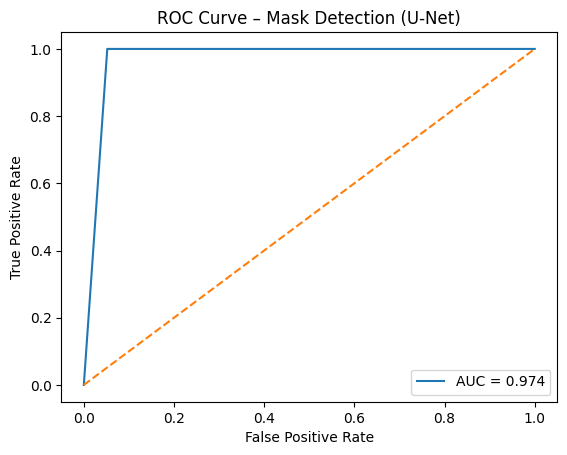

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Mask Detection (U-Net)")
plt.legend()
plt.show()